# UNSW-NB-15




Los paquetes de red sin procesar del conjunto de datos UNSW-NB 15 fueron creados por la herramienta IXIA PerfectStorm en el Cyber ​​Range Lab de UNSW Canberra para generar un híbrido de actividades normales modernas reales y comportamientos de ataque contemporáneos sintéticos.

La herramienta tcpdump se utilizó para capturar 100 GB de tráfico sin procesar (por ejemplo, archivos Pcap).
Este conjunto de datos tiene nueve tipos de ataques, a saber,

* **Fuzzers**: Intentos de causar errores enviando datos aleatorios/inválidos.

* **Analysis**: Ataques que incluyen escaneo de puertos o spam.

* **Backdoors**: Entradas secretas que saltan la seguridad normal.

* **DoS (Denegación de Servicio)**: Intentos de sobrecargar un recurso.

* **Exploits**: Aprovechamiento de vulnerabilidades conocidas.

* **Generic**: Ataques que funcionan contra cifrados de bloque.

* **Reconnaissance (Reconocimiento)**: Recopilación de información de la red.

* **Shellcode**: Pequeños fragmentos de código usados para explotar software.

* **Worms**: Software malicioso que se replica a otros equipos.

Se utilizan las herramientas Argus, Bro-IDS y se desarrollan doce algoritmos para generar un total de 49 características con la etiqueta de clase.

dataset usado acá vs el que se lista en kaggle (indicando su posición de columna)
#### Comparativa de Columnas (Dataset Actual vs. Kaggle)

| N° | Columna | Descripción Traducida |
| --- | --- | --- |
| 1 | `id` | Identificador único del registro. |
| 2 | `dur` | Duración total del registro (float). |
| 3 | `proto` | Protocolo de transacción (nominal). |
| 4 | `service` | Servicio usado (http, ftp, smtp, ssh, dns, etc.). |
| 5 | `state` | Estado y su protocolo dependiente (ACC, CLO, CON, etc.). |
| 6 | `spkts` | Conteo de paquetes de origen a destino (int). |
| 7 | `dpkts` | Conteo de paquetes de destino a origen (int). |
| 8 | `sbytes` | Bytes de transacción de origen a destino (int). |
| 9 | `dbytes` | Bytes de transacción de destino a origen (int). |
| 10 | `rate` | Tasa de transmisión (no presente en todos los sets). |
| 11 | `sttl` | Valor de tiempo de vida (TTL) de origen a destino (int). |
| 12 | `dttl` | Valor de tiempo de vida (TTL) de destino a origen (int). |
| 13 | `sload` | Bits por segundo del origen (float). |
| 14 | `dload` | Bits por segundo del destino (float). |
| 15 | `sloss` | Paquetes de origen retransmitidos o perdidos (int). |
| 16 | `dloss` | Paquetes de destino retransmitidos o perdidos (int). |
| 17 | `sinpkt` | Tiempo de llegada entre paquetes del origen (mSec). |
| 18 | `dinpkt` | Tiempo de llegada entre paquetes del destino (mSec). |
| 19 | `sjit` | Jitter (variación de retraso) del origen (mSec). |
| 20 | `djit` | Jitter (variación de retraso) del destino (mSec). |
| 21 | `swin` | Valor de ventana TCP anunciado por el origen. |
| 22 | `stcpb` | Número de secuencia base TCP del origen. |
| 23 | `dtcpb` | Número de secuencia base TCP del destino. |
| 24 | `dwin` | Valor de ventana TCP anunciado por el destino. |
| 25 | `tcprtt` | Tiempo de ida y vuelta de la conexión TCP (synack + ackdat). |
| 26 | `synack` | Tiempo entre paquetes SYN y SYN_ACK. |
| 27 | `ackdat` | Tiempo entre paquetes SYN_ACK y ACK. |
| 28 | `smean` | Promedio del tamaño del paquete transmitido por el origen. |
| 29 | `dmean` | Promedio del tamaño del paquete transmitido por el destino. |
| 30 | `trans_depth` | Profundidad de la transacción HTTP (pipelined). |
| 31 | `res_body_len` | Tamaño real del contenido transferido desde el servidor HTTP. |
| 32 | `ct_srv_src` | Nº de conexiones con mismo servicio y dirección origen en 100 conex. |
| 33 | `ct_state_ttl` | Nº de conexiones según estado y rango de TTL. |
| 34 | `ct_dst_ltm` | Nº de conexiones a la misma dirección de destino en 100 conex. |
| 35 | `ct_src_dport_ltm` | Nº de conexiones con misma IP origen y puerto destino en 100 conex. |
| 36 | `ct_dst_sport_ltm` | Nº de conexiones con misma IP destino y puerto origen en 100 conex. |
| 37 | `ct_dst_src_ltm` | Nº de conexiones con mismo origen y destino en 100 conex. |
| 38 | `is_ftp_login` | Binario: 1 si la sesión FTP tiene usuario/pass; 0 si no. |
| 39 | `ct_ftp_cmd` | Nº de flujos que tienen un comando en la sesión FTP. |
| 40 | `ct_flw_http_mthd` | Nº de flujos con métodos HTTP (Get/Post). |
| 41 | `ct_src_ltm` | Nº de conexiones de la misma dirección de origen en 100 conex. |
| 42 | `ct_srv_dst` | Nº de conexiones con mismo servicio y dirección destino en 100 conex. |
| 43 | `is_sm_ips_ports` | Binario: 1 si IP/puerto de origen y destino son iguales. |
| 44 | `attack_cat` | Nombre de la categoría del ataque (Fuzzers, DoS, etc.). |
| 45 | `label` | Etiqueta binaria (0 = normal, 1 = ataque). |

del dataset que usamos en este colab vs el de kaggle https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15?select=UNSW_NB15_training-set.csv me sobra el **rate** y el **id**

del dataset original me faltan

1.	srcip: Source IP address
2.	sport: Source port number (integer)
3.	dstip: Destination IP address (nominal)
4.	dsport: Destination port number (integer)
29.	Stime: Record start time (timestamp)
30.	Ltime: Record last time (timestamp)



## Análisis exploratorio

**Lectura datos**

Leer los conjuntos de datos y combinar los conjuntos de entrenamiento y prueba en un DataFrame

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#matplotlib inline

import warnings
warnings.filterwarnings('ignore')

#trabajar con un subconjunto mientras construimos código
#url_train = 'UNSW_NB15_training-set.csv'
url_test = 'UNSW_NB15_testing-set.csv'

#df = pd.read_csv(url_train)
#df_test = pd.read_csv(url_test)

#df_total = pd.concat([df, df_test])
df_total = pd.read_csv(url_test)

In [2]:
df_total.shape

(175341, 45)

In [3]:
##Exploramos las primeras observaciones
df_total.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


 **conteo de datos nulos**

In [4]:
df_total.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

**Observar datos primera instancia**

In [5]:
df_total.iloc[0]

id                             1
dur                     0.121478
proto                        tcp
service                        -
state                        FIN
spkts                          6
dpkts                          4
sbytes                       258
dbytes                       172
rate                    74.08749
sttl                         252
dttl                         254
sload                14158.94238
dload                8495.365234
sloss                          0
dloss                          0
sinpkt                   24.2956
dinpkt                     8.375
sjit                   30.177547
djit                   11.830604
swin                         255
stcpb                  621772692
dtcpb                 2202533631
dwin                         255
tcprtt                       0.0
synack                       0.0
ackdat                       0.0
smean                         43
dmean                         43
trans_depth                    0
response_b

**revisión/eliminación de datos nulos**


In [6]:
df_total.isna().sum()
df_total=df_total.dropna()
df_total.shape
# ANTES: (175341, 45)

(175341, 45)

**Histograma**

<Figure size 1200x1000 with 0 Axes>

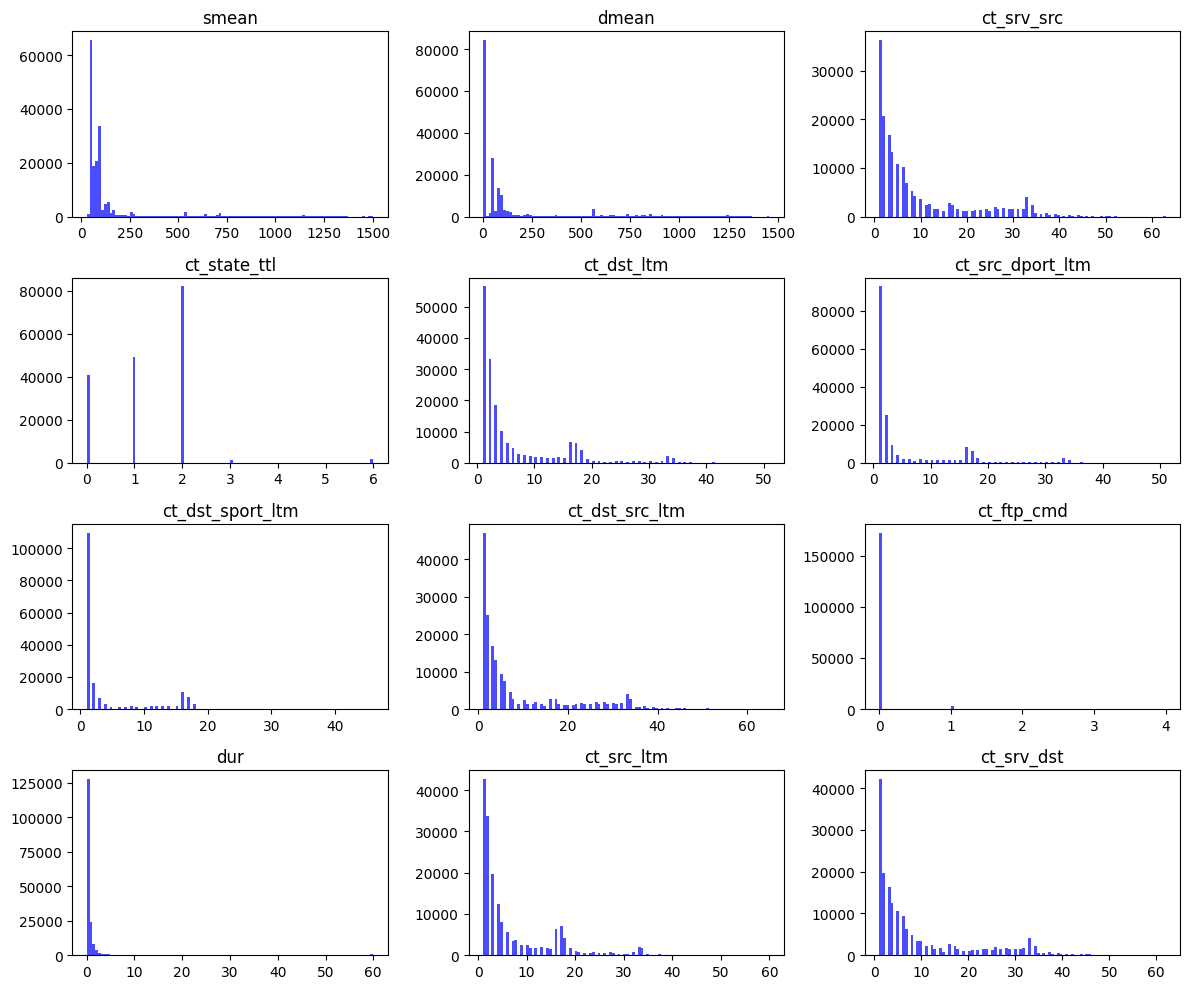

In [7]:
import matplotlib.pyplot as plt

# hacemos un subset con solo las variables cuantitativas
#'rate', 'ct_flw_http_mthd'
var_cuantis = [ 'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'dur', 'ct_src_ltm', 'ct_srv_dst']

datos_cuanti = df_total[var_cuantis]

# Crear un histograma de cada variable en una matriz de 4x3
num_rows = 4
num_cols = 3
plt.figure(figsize=(12, 10))
plt.figure(figsize=(12, 10))

for i, column in enumerate(datos_cuanti.columns):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.hist(datos_cuanti[column], bins=100, color='blue', alpha=0.7)
    plt.title(column)

plt.tight_layout()
plt.show()

**Variables cualitativas**

In [8]:
##Primero hacemos el conteo de cada variable y lo guardamos con un nombre
freq_proto = df_total['proto'].value_counts()
freq_service = df_total['service'].value_counts()
freq_state = df_total['state'].value_counts()
freq_attack_cat = df_total['attack_cat'].value_counts()
freq_Label = df_total['label'].value_counts()


print(freq_proto)
print(freq_service)
print(freq_attack_cat)
print(freq_Label)

tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
          ...  
rdp          98
netblt       98
igmp         18
icmp         15
rtp           1
Name: proto, Length: 133, dtype: int64
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: service, dtype: int64
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: attack_cat, dtype: int64
1    119341
0     56000
Name: label, dtype: int64


In [9]:
##Segundo hacemos el conteo para una variable en particular que tiene los tipos de ataques en caso de que el label diga que es ataque
filtro=df_total['label']==1
soloataques=df_total[filtro]

generico=df_total[(df_total['attack_cat']=='Generic')]              #58871
Exploits=df_total[(df_total['attack_cat']=='Exploits') ]            #44525
Fuzzers=df_total[(df_total['attack_cat']=='Fuzzers') ]              #24246
DoS=df_total[(df_total['attack_cat']=='DoS') ]                      #16353
Reconnaissance=df_total[(df_total['attack_cat']=='Reconnaissance') ]#13987
Analysis=df_total[(df_total['attack_cat']=='Analysis') ]            #2677
Backdoor=df_total[(df_total['attack_cat']=='Backdoor') ]            #2329
Shellcode=df_total[(df_total['attack_cat']=='Shellcode') ]          #1511
Worms=df_total[(df_total['attack_cat']=='Worms') ]                  #174

freq_attacks = soloataques['attack_cat'].value_counts()
print(freq_attacks)


Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: attack_cat, dtype: int64


Text(0, 0.5, 'Frecuencia')

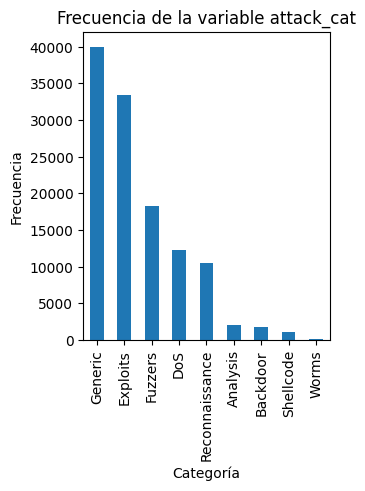

In [10]:
# Configuramos el tamaño de la figura
plt.figure(figsize=(7, 4))

# Graficamos la frecuencia de la variable attack_cat
plt.subplot(1, 2, 1)
freq_attacks.plot(kind='bar')
plt.title('Frecuencia de la variable attack_cat')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')

In [11]:
soloataques.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,119341.000000,119341.000000,119341.000000,119341.000000,1.193410e+05,1.193410e+05,1.193410e+05,119341.000000,119341.000000,1.193410e+05,...,119341.000000,119341.000000,119341.000000,119341.000000,119341.000000,119341.000000,119341.000000,119341.000000,119341.0,119341.0
mean,112884.303391,1.519969,15.405946,10.012619,1.106866e+04,7.364456e+03,1.336997e+05,228.395732,86.804602,9.704916e+07,...,7.067998,5.621471,11.010348,0.013994,0.013994,0.140656,8.313748,10.781148,0.0,1.0
std,37453.154374,7.109044,160.975456,111.177484,2.116586e+05,1.447241e+05,1.828434e+05,65.578030,119.427812,1.990572e+08,...,9.097151,6.401592,12.101349,0.124393,0.124393,0.779014,9.421860,12.060996,0.0,0.0
min,47912.000000,0.000000,1.000000,0.000000,6.000000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,1.0
25%,79711.000000,0.000006,2.000000,0.000000,1.140000e+02,0.000000e+00,3.407855e+01,254.000000,0.000000,1.377625e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,1.0
50%,115504.000000,0.000009,2.000000,0.000000,2.000000e+02,0.000000e+00,1.111111e+05,254.000000,0.000000,5.066666e+07,...,2.000000,2.000000,5.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.0,1.0
75%,145506.000000,0.679699,10.000000,8.000000,8.480000e+02,3.540000e+02,1.666667e+05,254.000000,252.000000,1.000000e+08,...,14.000000,11.000000,19.000000,0.000000,0.000000,0.000000,16.000000,19.000000,0.0,1.0
max,175341.000000,59.999046,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,252.000000,5.988000e+09,...,51.000000,31.000000,65.000000,4.000000,4.000000,30.000000,60.000000,52.000000,0.0,1.0


In [12]:
#en que rangos se mueven las variables cuantitativas dependiendo de si son ataques o no - son similares?
var_medias = ['dur', 'rate','sbytes','dbytes', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'label' ]

media_por_categoria = df_total[var_medias].groupby('label').mean()

print(media_por_categoria)


            dur           rate        sbytes        dbytes         sload  \
label                                                                      
0      1.017177   13799.312118   4105.702929  31049.463143  2.317070e+07   
1      1.519969  133699.690589  11068.655357   7364.456256  9.704916e+07   

              dload       sinpkt      dinpkt         sjit        djit  \
label                                                                   
0      2.062949e+06  2847.882467  121.196678  5440.295684  965.215178   
1      1.813877e+04   112.289583   72.740464  4758.505744  435.021948   

         tcprtt    synack    ackdat  
label                                
0      0.031945  0.017327  0.014618  
1      0.045830  0.022754  0.023077  


In [13]:
## Para las variables cualitativas podemos hacer lo siguiente

var_frecuencias = [ "proto"]

# Calculamos la frecuencia de categorías de sexo separada por source
frequencies = df_total[var_frecuencias].groupby(['proto']).size().reset_index(name='frecuencia')

print(frequencies)

         proto  frecuencia
0          3pc         100
1          a/n         100
2    aes-sp3-d         100
3          any         300
4        argus          98
..         ...         ...
128        wsn         100
129       xnet          99
130    xns-idp          99
131        xtp         100
132       zero         100

[133 rows x 2 columns]


## Attack vs No Attack (MODELOS)

### 1. Codificación de Variables (Preparación de datos)

In [14]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Se hace una copia del dataset original para no alterar los datos iniciales
df_attack = df_total.copy()

# Se inicializan múltiples herramientas llamadas 'LabelEncoder'. 
# Su función es tomar las categorías en formato texto y asignarles un número.
LE_proto = LabelEncoder()
LE_service = LabelEncoder()
LE_state = LabelEncoder()
LE_attack_cat = LabelEncoder()
LE_label = LabelEncoder()


df_attack['proto'] = LE_proto.fit_transform(df_attack['proto']) # Se aplica el LabelEncoder a cada característica (feature) y se sobrescribe 
#                                                                 la columna con valores numéricos. fit_transform "aprende" las categorías y 
#                                                                 las convierte a números al mismo tiempo.
joblib.dump(LE_proto, 'LE_proto.pkl') # joblib.dump guarda este "aprendizaje" en un archivo local (.pkl) para poder reusar la misma 
#                                       codificación en el futuro (por ejemplo, al predecir datos en producción)

df_attack['service'] = LE_service.fit_transform(df_attack['service'])
joblib.dump(LE_service, 'LE_service.pkl')

df_attack['state'] = LE_state.fit_transform(df_attack['state'])
joblib.dump(LE_state, 'LE_state.pkl')

df_attack['attack_cat'] = LE_attack_cat.fit_transform(df_attack['attack_cat'])
joblib.dump(LE_attack_cat, 'LE_attack_cat.pkl')

df_attack['label'] = LE_label.fit_transform(df_attack['label'])
#joblib.dump(LE_label, 'LE_label.pkl')

df_attack.head()



,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,113,0,2,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,6,0
1,2,0.649902,113,0,2,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,6,0
2,3,1.623129,113,0,2,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,6,0
3,4,1.681642,113,3,2,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,6,0
4,5,0.449454,113,0,2,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,6,0


### 2. Separación de Variables Predictoras (X) y Etiquetas (y)

In [15]:
# Identificamos cuál es la variable a predecir (la etiqueta 'y')
# En este caso, asignamos la columna 'label' entera a nuestra 'y_total' (valores 0 ó 1)
y_total = df_attack['label']

# Retiramos del grupo de datos original las columnas que no nos sirven para predecir si es un ataque.
# - 'id' es solo un identificador autoincremental sin valor predecible
# - 'attack_cat' es la categoría, la borramos para que el modelo no se entrene haciendo trampa 
#   y porque ahora solo queremos una predicción binaria.
# - 'label' ya se guardó en y_total.
df_attack = df_attack.drop(['id','attack_cat','label'], axis=1)

# Se toma la tabla de datos procesados (un DataFrame de Pandas) y se saca 
# solamente su matriz de valores crudos (un arreglo NumPy).
X_real = df_attack.values

# NOTA: En el código original se tienen líneas comentadas que usan StandardScaler(). Es una práctica opcional (pero recomendada) 
# para estandarizar los datos haciendo que sigan una distribución más equilibrada.

# En este caso NO es estrictamente necesario: El modelo que estás usando aquí es un Árbol de Decisión (DecisionTreeClassifier). 
# Los árboles funcionan buscando puntos de corte (por ejemplo: ¿duración > 1.5?). A los árboles no les afectan las diferencias 
# de escala entre las variables, por lo que estandarizar o no casi no cambiará el resultado.

# CUANDO SÍ USAR: Si en el futuro cambias el modelo a Redes Neuronales, Máquinas de Vectores de Soporte (SVM), Regresión Logística o 
# K-Vecinos más Cercanos (KNN). Estos modelos usan cálculos matemáticos de "distancia" y si no estandarizas, fallarán o rendirán muy mal.

#scaler = StandardScaler()
#scaler.fit(X_real)

X_total = X_real
#scaler.transform(X_real)

n_classes = 2


### 3. Entrenamiento del Modelo de Árbol de Decisión

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# crear clasificador
# Se reserva memoria para nuestro modelo de aprendizaje, que es un clasificador 
# estructurado como árbol de decisiones.
clf = DecisionTreeClassifier(random_state=19)

# Revolvemos y partimos los datos totales (X e y) en una relación de 70% para 
# entrenamiento (tr) y 30% reservado para evaluar el modelo después (t / test_size=0.30)
X_tr, X_t, y_tr, y_t = train_test_split(X_total, y_total, test_size=0.30, random_state=19)

print("- Attack vs Normal -")

# Se crea una tabla para almacenar el resumen de rendimiento en un futuro,
performance_attack = pd.DataFrame(columns=["Classifier", "accuracy", "recall", "precision", "f1"])

# entrenamos con datos entrenamiento
# La orden fundamental 'fit': obliga al árbol de decisión a deducir patrones usando 
# las entradas (X_tr) contra sus resultados reales correspondientes (y_tr)
clf = clf.fit(X_tr, y_tr)

- Attack vs Normal -


### 4. Evaluación y Comportamiento con los Datos

In [17]:
# como nos va con los datos de testing
# Ordenamos al modelo generar intentos de adivinanza (predicciones) sobre el 30% 
# de datos no vistos
y_predict = clf.predict(X_t)

# A partir de este momento, generamos las evaluaciones comparando las predicciones (y_predict) 
# versus el resultado genuino que siempre debió haber tenido (y_t)
accuracy = accuracy_score(y_t, y_predict)      # El porcentaje general de aciertos
recall = recall_score(y_t, y_predict)          # Sensibilidad: cuántos ataques reales capturó el modelo
precision = precision_score(y_t, y_predict)    # Efectividad: si el modelo dice de que es ataque, qué tan probable es que lo sea
f1 = f1_score(y_t, y_predict)                  # Balancea la precisión y fiabilidad general (recall)

performance_attack.loc[0] = ["Decision Tree", accuracy, recall, precision, f1]

print(performance_attack)

# Un reporte con más detalles desgajado en las clases 0 o 1
# Útil si queremos saber qué tan bueno es prediciendo únicamente los que no son ataques (0)
print("")
print("Classification Report:")
print(classification_report(y_t, y_predict))

# Permite visualizar cómo se confunde el modelo (Ej. Falsos Negativos y Falsos Positivos)
matriz_confusion = confusion_matrix(y_t, y_predict)
print("Matriz de Confusión:")
print(matriz_confusion)


      Classifier  accuracy    recall  precision        f1
0  Decision Tree  0.947151  0.960176   0.961742  0.960958

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     16971
           1       0.96      0.96      0.96     35632

    accuracy                           0.95     52603
   macro avg       0.94      0.94      0.94     52603
weighted avg       0.95      0.95      0.95     52603

Matriz de Confusión:
[[15610  1361]
 [ 1419 34213]]


#### Análisis de reportes

* **Accuracy (Exactitud = 0.9472 o 94.72%)**: De todas las 52,603 predicciones que hizo sobre los datos de prueba, acertó el 94.72% de las veces.
* **Recall (Exhaustividad = 0.9602 o 96.06%)**: De todos los ciberataques reales que había camuflados en el sistema, el modelo fue capaz de detectar el 96.02% de ellos. Solo se le escapó un ~4%.
* **Precision (Precisión = 0.9617 o 96.17%)**: Cuando el modelo encendió la alarma y dijo "¡ESTO ES UN ATAQUE!", acertó el 96.17% de las veces. (Solo un ~3% fueron falsas alarmas).
* **F1 (F1-score = 0.9610 o 96.1%)**: Es una nota general que resulta de promediar matemáticamente la Precisión y el Recall. Como ambos valores son altos y están equilibrados, el F1 también lo es.

#### Matriz de confusión 

| | Predice Normal (0) | Predice Ataque (1) |
| :--- | :---: | :---: |
| **Realmente Normal (0)** | **15.610** (VN) | 1.361 (FP) |
| **Realmente Ataque (1)** | 1.419 (FN) | **34.213** (VP) |

* **Verdaderos Negativos (15.610):** Tráfico inofensivo identificado correctamente.
* **Verdaderos Positivos (34.213):** Ataques detectados y neutralizados con éxito.
* **Falsos Positivos (1.361):** "Falsa Alarma". Usuarios normales bloqueados por error.
* **Falsos Negativos (1.419):** "El gran peligro". Ataques que pasaron desapercibidos.

### EXTRA: Ajuste de hiperparámetros

Para que el modelo sea óptimo, no debemos dejar que el árbol crezca infinitamente. Vamos a usar GridSearchCV. Esto probará automáticamente varias combinaciones de parámetros para encontrar la mejor.

* **Parámetros**:

**max_depth**: Limita la profundidad del árbol. Es vital para que el modelo no "memorice" el ruido de UNSW-NB15.

**criterion**: Define la función para medir la calidad de la división. Gini es más rápido, entropy a veces da mejores resultados en datos complejos.

**min_samples_leaf**: El número mínimo de muestras requeridas para dividir un nodo interno o que debe tener una "hoja" final.

**Validación Cruzada (Cross-Validation, cv = 5)** es una técnica para asegurarnos de que el rendimiento del árbol de decisión no sea producto del azar o de haber tenido "suerte" con una parte específica de los datos de UNSW-NB15.

- El proceso: El conjunto de entrenamiento (X_tr) se divide en 5 partes iguales (llamadas folds).

- La rotación: El modelo se entrena 5 veces. En cada iteración, usa 4 partes para aprender y 1 parte para evaluarse.

- El resultado: Al final, se promedian los resultados de las 5 evaluaciones.

**Scoring (scoring='f1')** le dice al algoritmo qué debe considerar como un "buen modelo". Por defecto, muchos usan accuracy (exactitud), pero en ciberseguridad, la exactitud suele ser engañosa, por esto mismo buscaremos equilibrar la captura de ataque sin generar demasiadas falsas alarmas

In [18]:
"""from sklearn.model_selection import GridSearchCV

# Definimos el espacio de búsqueda
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced'] # Útil si hay pocos ataques comparado con tráfico normal
}

# Creamos el buscador
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=19), param_grid, cv=5, scoring='f1')

# Entrenamos buscando la mejor combinación
grid_search.fit(X_tr, y_tr)

print("Mejores parámetros encontrados:", grid_search.best_params_)
best_model = grid_search.best_estimator_"""

'from sklearn.model_selection import GridSearchCV\n\n# Definimos el espacio de búsqueda\nparam_grid = {\n    \'criterion\': [\'gini\', \'entropy\'],\n    \'max_depth\': [10, 20, 30, None],\n    \'min_samples_split\': [2, 5, 10],\n    \'class_weight\': [None, \'balanced\'] # Útil si hay pocos ataques comparado con tráfico normal\n}\n\n# Creamos el buscador\ngrid_search = GridSearchCV(DecisionTreeClassifier(random_state=19), param_grid, cv=5, scoring=\'f1\')\n\n# Entrenamos buscando la mejor combinación\ngrid_search.fit(X_tr, y_tr)\n\nprint("Mejores parámetros encontrados:", grid_search.best_params_)\nbest_model = grid_search.best_estimator_'

### **Sección 1**: Importación e Inicialización

In [19]:
import shap
import pandas as pd

# Inicializamos el soporte de javascript para que los gráficos interactivos de SHAP se dibujen correctamente
shap.initjs()

### **Sección 2**: Preparación de Datos y Cálculo SHAP

In [20]:
# Guardamos los nombres originales de las características del dataset
column_names = df_attack.columns

# Convertimos la matriz de test (X_t) a un DataFrame para que SHAP reconozca las etiquetas
X_t_dataframe = pd.DataFrame(X_t, columns=column_names)

# Instanciamos el "Explicador" de SHAP. 
# Le pasamos el modelo (el Árbol de Decisión 'clf') que queremos auditar
explainer = shap.Explainer(clf)

# ATENCIÓN: Esta línea calcula la fuerza de cada variable. 
# Puede tardar unos segundos/minutos porque evalúa registro por registro.
shap_values_clf = explainer.shap_values(X_t_dataframe)


In [21]:
#generamos un gráfico que nos permite visualizar el resultado de los valores Shap.
shap_values_clf

[array([[ 8.54566945e-04,  8.27678095e-04,  3.49798972e-05, ...,
         -8.40555634e-05,  4.99237410e-02,  0.00000000e+00],
        [ 3.38990434e-03,  2.08452228e-05,  1.27534653e-03, ...,
         -2.03664218e-03,  1.80645450e-02,  0.00000000e+00],
        [ 1.17048053e-02, -1.29841986e-04,  1.52401470e-02, ...,
          1.59350284e-04,  2.11784202e-01,  0.00000000e+00],
        ...,
        [ 3.26906982e-03, -4.38089205e-04, -1.06256527e-02, ...,
         -2.08868504e-03, -5.51480576e-02,  0.00000000e+00],
        [ 1.51336446e-03, -2.26993690e-03, -2.66883433e-03, ...,
          2.28603242e-03,  4.42620747e-02,  0.00000000e+00],
        [-1.89823918e-03,  6.21101905e-03,  8.39522081e-04, ...,
         -6.74126606e-03, -5.25115347e-02,  0.00000000e+00]]),
 array([[-8.54566945e-04, -8.27678095e-04, -3.49798972e-05, ...,
          8.40555634e-05, -4.99237410e-02,  0.00000000e+00],
        [-3.38990434e-03, -2.08452228e-05, -1.27534653e-03, ...,
          2.03664218e-03, -1.80645450e

### **Sección 3**: Visualización del Resumen (Summary Plot)

Este comando imprimirá un gráfico muy famoso de SHAP. En él verás una lista de tus variables ordenadas de arriba a abajo por su importancia. Las características de arriba fueron las más críticas para detener ciberataques.

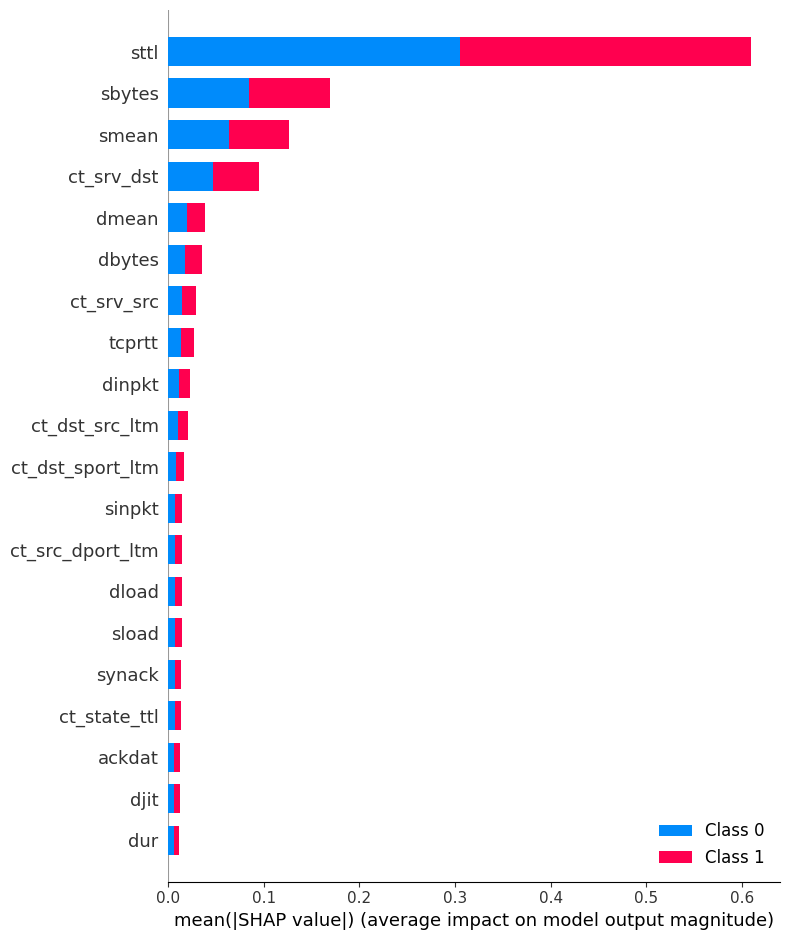

In [22]:
#Generamos el grafico que esta en la opcion de la librería shap
shap.summary_plot(shap_values_clf, X_t_dataframe)

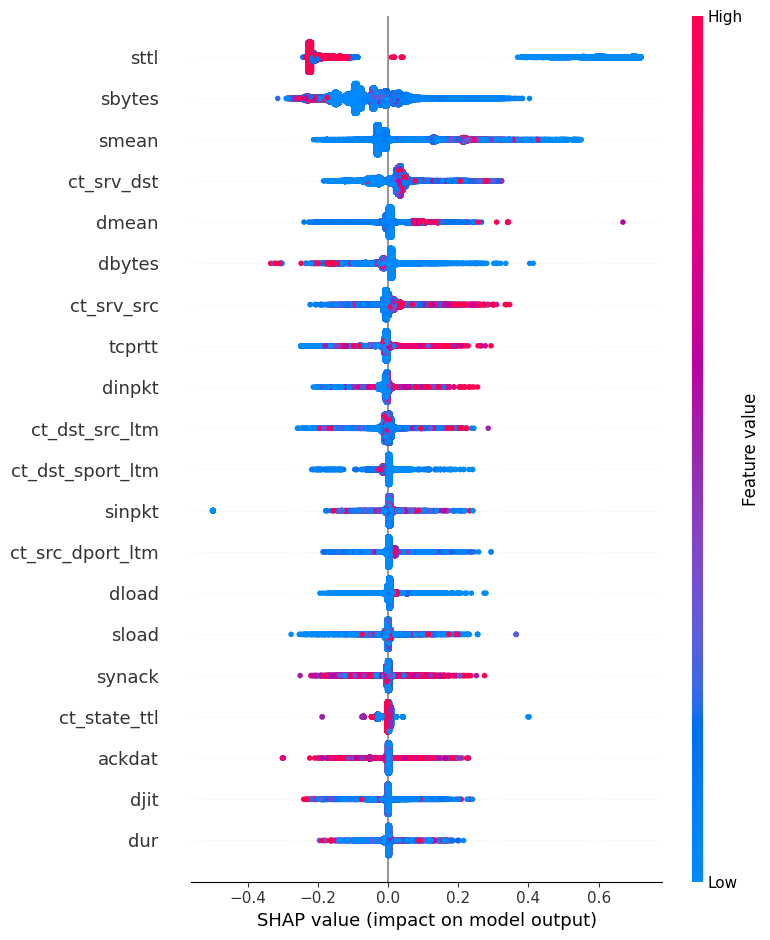

In [23]:
##Ahora probamos con la etiqueta "Normal"
shap.summary_plot(shap_values_clf[0], X_t_dataframe)

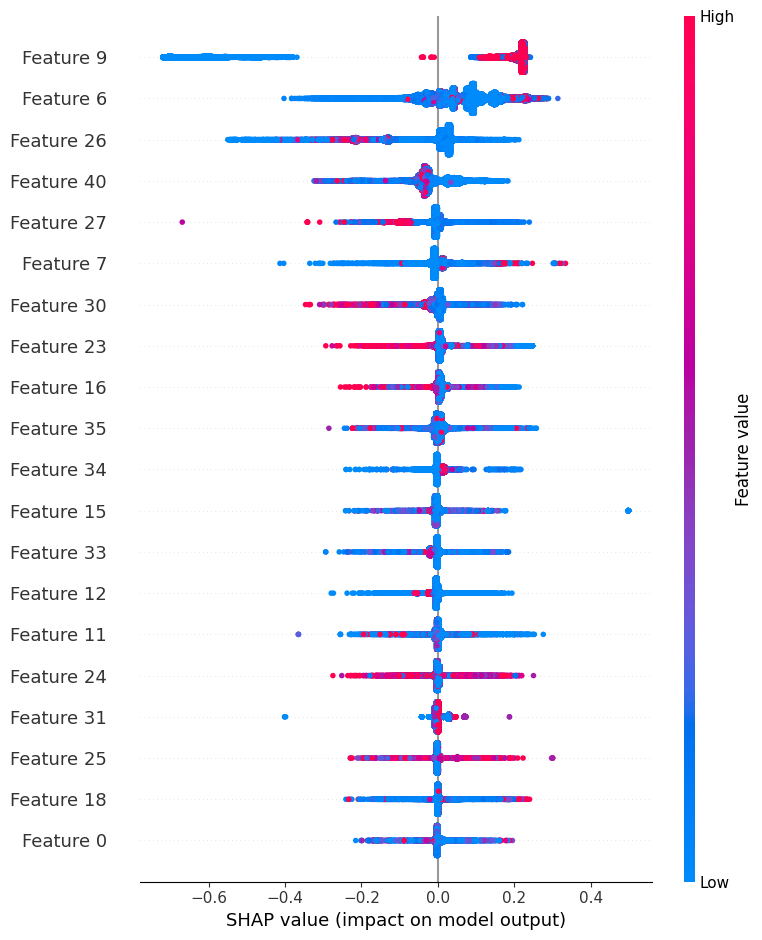

In [24]:
##Ahora probamos con la etiqueta "Ataque"
shap.summary_plot(shap_values_clf[1], X_t)

Text(0.5, 1.0, 'Importancia de las características para Ataque')

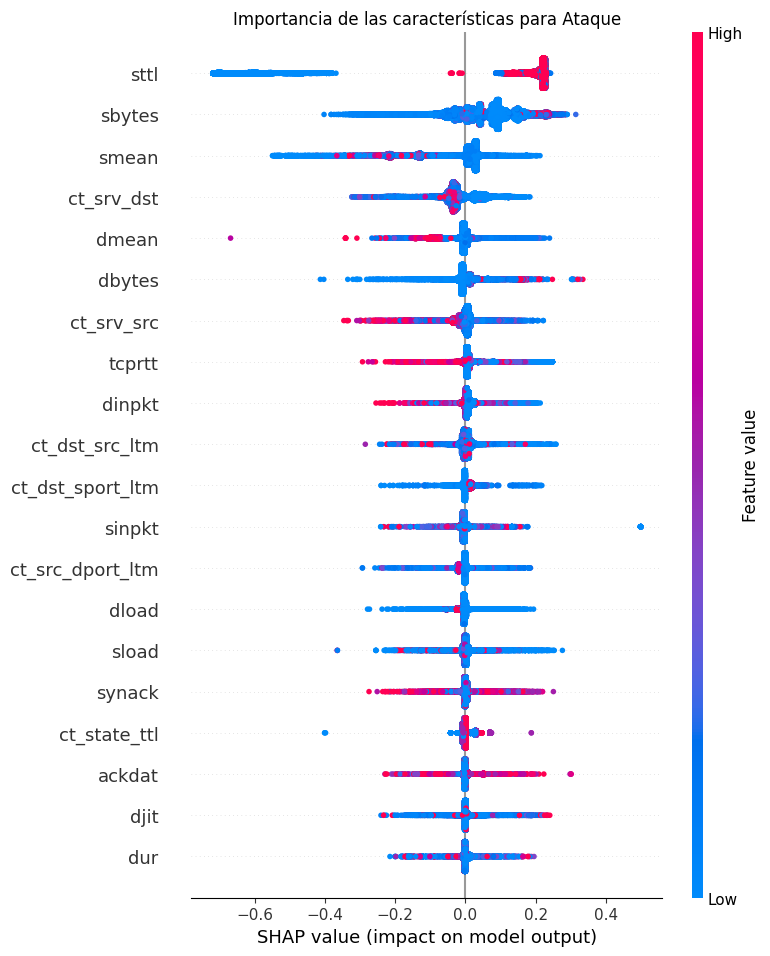

In [25]:
##Ahora probamos con la etiqueta "Ataque"
shap.summary_plot(shap_values_clf[1], X_t_dataframe, show=False)
plt.title(f"Importancia de las características para Ataque")

### **Sección 4**: Guardado y Carga del Modelo

In [26]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Guardamos el modelo de árbol de decisión ya entrenado en el disco duro
joblib.dump(clf, 'modelo_entrenado.pkl')

# Simulamos que abrimos el programa de nuevo y cargamos todo lo necesario
clasificador = joblib.load('modelo_entrenado.pkl')

# Cargamos también los "traductores" (LabelEncoders) que hicimos al principio
# Esto es vital porque el usuario ingresará datos en texto (como "tcp", "http") 
# y el modelo solo entiende los números que le asignamos antes.
LE_proto = joblib.load('LE_proto.pkl')
LE_service = joblib.load('LE_service.pkl')
LE_state = joblib.load('LE_state.pkl')

### **Sección 5**: El Simulador de Predicción ("En vivo")

In [27]:
# Instancia de ejemplo proporcionada por el usuario

# normal "1,2.093085,tcp,smtp,FIN,62,28,56329,2212,42.520967,62,252,211825.125,8152.559082,28,8,34.312868,75.092445,3253.278833,106.113453,255,1824722662,860716719,255,0.13114,0.052852,0.078288,909,79,0,0,2,1,1,1,1,2,0,0,0,1,1,0,Normal, 0"
# Backdoor 48017,0.283214,tcp,http,FIN,10,6,624,268,52.963483,62,252,15874.9209,6327.370605,2,1,28.336,45.470398,1427.461316,64.724004,255,2972617788,2051729691,255,0.072382,0.055856,0.016526,62,45,1,0,1,1,1,1,1,1,0,0,1,1,1,0,Backdoor,1
# Fuzzer 48018,0.67547,tcp,ftp,FIN,12,12,2616,682,34.050365,254,252,28400.96484,7414.09668,3,4,61.406365,52.081363,3035.186668,64.822973,255,2162593193,2671705107,255,0.162189,0.101743,0.060446,218,57,0,0,3,1,2,2,1,3,0,0,0,5,3,0,Fuzzers,1
# Analysis 48449,17.330788,ospf,-,INT,28,0,12832,0,1.557921,254,0,5711.916016,0,0,0,641.881062,0,746.488812,0,0,0,0,0,0,0,0,458,0,0,0,1,2,1,1,1,1,0,0,0,2,1,0,Analysis,1
# DoS 49413,0.000003,fire,-,INT,2,0,200,0,333333.3215,254,0,266666656,0,0,0,0.003,0,0,0,0,0,0,0,0,0,0,100,0,0,0,5,2,2,2,2,5,0,0,0,2,5,0,DoS,1
# Reconocimiento 49405,1.089362,pim,-,INT,8,0,480,0,6.425779,254,0,3084.374023,0,0,0,155.623141,0,372.314781,0,0,0,0,0,0,0,0,60,0,0,0,1,2,1,1,1,1,0,0,0,1,1,0,Reconnaissance,1
# Exploit 49406,0.000008,ptp,-,INT,2,0,200,0,125000.0003,254,0,100000000,0,0,0,0.008,0,0,0,0,0,0,0,0,0,0,100,0,0,0,2,2,1,1,1,2,0,0,0,26,2,0,Exploits,1
# Worm 49960,0.338518,tcp,http,FIN,66,14,78481,612,233.370165,254,252,1826597.125,13446.84766,30,1,4.991231,25.489846,514.881352,38.656297,255,2381717425,307268346,255,0.05277,0.007146,0.045624,1189,44,1,0,1,1,1,1,1,1,0,0,1,1,1,0,Worms,1
# shellcode 50028,0.000003,udp,-,INT,2,0,130,0,333333.3215,254,0,173333328,0,0,0,0.003,0,0,0,0,0,0,0,0,0,0,65,0,0,0,1,2,1,1,1,1,0,0,0,1,1,0,Shellcode,1
# Generic 117205,0.000003,udp,dns,INT,2,0,114,0,333333.3215,254,0,152000000,0,0,0,0.003,0,0,0,0,0,0,0,0,0,0,57,0,0,0,22,2,22,22,10,22,0,0,0,22,22,0,Generic,1

# Solicita al usuario que ingrese la instancia
instancia = input("Ingresa los valores de la instancia (separados por comas): ")

# Separar los valores por ',' y eliminar 'id', 'attack_cat' y 'label'
valores = instancia.split(',')
valores = [valores[i] for i in range(len(valores)) if i not in [0, len(valores)-2, len(valores)-1]]

# Traducimos las palabras a números usando los encoders previamente cargados
valores[1] = LE_proto.transform([valores[1]])[0]  # Convierte 'proto' (ej. tcp -> 113)
valores[2] = LE_service.transform([valores[2]])[0] if valores[2] in LE_service.classes_ else -1  # 'service'
valores[3] = LE_state.transform([valores[3]])[0]  # 'state'

# El modelo necesita que todos los números sean decimales (float) para procesarlos, excepto
# los que acabamos de traducir (posiciones 1, 2 y 3) que ya son identificadores válidos.
muestra = [float(x) if i != 1 and i != 2 and i != 3 else x for i, x in enumerate(valores)]

# Realiza la predicción utilizando el modelo cargado
prediction = clasificador.predict([muestra])

# Imprime las predicciones
print("el tráfico es clasificado como:", 'normal' if prediction == 0 else 'ataque!')


IndexError: list index out of range

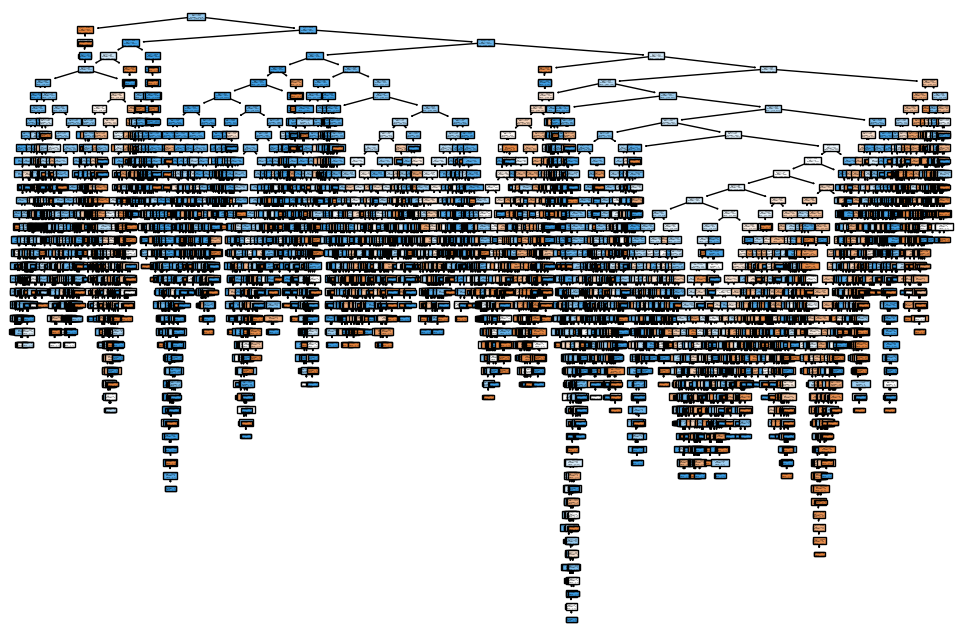

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree


# Visualizar el árbol de decisión
plt.figure(figsize=(12, 8))  # Establecer el tamaño de la figura
plot_tree(clf, filled=True)
plt.show()
